In [1]:
from glm_based_event_analysis.utils.general import load_config
from glm_based_event_analysis.utils.graph import remove_edges_from_graph
import numpy as np
import networkx as nx
import pickle
import json

In [2]:
COMPUTE_LENGTHS = True

# Carregando grafo e removendo arestas de teste

In [3]:
with open("/exp_local/kenzosaki/data/iptc/graphs/politics_event_graph.pkl", "rb") as f:
    G = pickle.load(f)

In [4]:
with open("/exp_local/kenzosaki/data/iptc/labels/politics_labels.json") as f:
    test_edges = json.load(f)

In [5]:
G_train = remove_edges_from_graph(G, test_edges)

In [6]:
# comparando G com G_train
print(f"Número de nós em G: {G.number_of_nodes()}")
print(f"Número de nós em G_train: {G_train.number_of_nodes()}")
print(f"Número de arestas em G: {G.number_of_edges()}")
print(f"Número de arestas em G_train: {G_train.number_of_edges()}") 
print(f"Componentes conexas em G: {nx.number_connected_components(G.to_undirected())}")
print(f"Componentes conexas em G_train: {nx.number_connected_components(G_train.to_undirected())}") 

Número de nós em G: 9890
Número de nós em G_train: 8863
Número de arestas em G: 21473
Número de arestas em G_train: 18689
Componentes conexas em G: 1
Componentes conexas em G_train: 304


In [7]:
# TODO: componentes conexas pequenas são um problema?. no minimo testar esta condição na serialização
for cc in nx.connected_components(G_train.to_undirected()):
    print(f"- Componente conexa com {len(cc)} nós")

- Componente conexa com 8188 nós
- Componente conexa com 2 nós
- Componente conexa com 1 nós
- Componente conexa com 2 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 6 nós
- Componente conexa com 2 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 2 nós
- Componente conexa com 16 nós
- Componente conexa com 1 nós
- Componente conexa com 3 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 3 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 1 nós
- Componente conexa com 3 nós
- Componente conexa com 39 nós
- Componente conexa com 2 nós
- Componente conexa com 1 nós
- Componente conexa com 4 nós
- Componente conexa com 1 nós
- Com

In [8]:
train_nodes = list(G_train.nodes())

# Serialização

In [9]:
from glm_based_event_analysis.random_walks.neighbourhood_serialization import NeighbourhoodSerializer
from glm_based_event_analysis.random_walks.sampler import RandomWalkSampler
import random

In [10]:
config = load_config("../src/glm_based_event_analysis/config/neighbourhood_serialization/gemini_flash.yaml", print_config=True)

Loaded configuration file (../src/glm_based_event_analysis/config/neighbourhood_serialization/gemini_flash.yaml):
	 general: {'use_ego_graph': False, 'use_support_anchors': False, 'n_support_anchors': 10}
	 ego_graph: {'radius': 5}
	 random_walks: {'bias': 'none', 'num_walks': 1, 'walk_length': 5, 'inverted': True}


In [11]:
def get_node_info(nodeid, G):

    node_attr = G.nodes[nodeid]
    event_dict = {
        "event_id": nodeid,
        "what": node_attr["what"],
        "when": node_attr["when"].strftime("%Y-%m-%d-%H:%M:%S") if not isinstance(node_attr["when"], (str)) else node_attr["when"],
        "where": node_attr["where"],
        "who": node_attr["who"],
        "why": node_attr["why"],
        "how": node_attr["how"],
    }

    return event_dict


In [12]:
# TODO: setar seed para garantir reprodutibilidade depois

In [13]:
anchor_node = random.choice(train_nodes)
anchor_node

'76_political_violence_electoral_tool_colombia_2026-05-27'

In [14]:
config

{'general': {'use_ego_graph': False,
  'use_support_anchors': False,
  'n_support_anchors': 10},
 'ego_graph': {'radius': 5},
 'random_walks': {'bias': 'none',
  'num_walks': 1,
  'walk_length': 5,
  'inverted': True}}

In [15]:
config["general"]["use_ego_graph"] = False
config["general"]["use_support_anchors"] = False
config["general"]["n_support_anchors"] = 3
config["random_walks"]["num_walks"] = 1
config["random_walks"]["inverted"] = True

In [16]:
neigh_serializer = NeighbourhoodSerializer(config, G_train)

In [17]:
ex = neigh_serializer.get_neighbourhood_representation(anchor_node)
print(ex)
print(anchor_node)
print(json.dumps(get_node_info(anchor_node, G_train), indent=2))

[
  {
    "source": "76_political_violence_electoral_tool_colombia_2026-05-27",
    "walk": [
      {
        "what": "Violence and the role of armed groups in Colombia's election campaign",
        "who": "Armed groups and political actors in Colombia",
        "when": "2026-05-19-07:00:00",
        "where": "Colombia",
        "why": "Influence and control during the election campaign",
        "how": "Through acts of violence and presence of armed groups"
      }
    ],
    "walk_ids": [
      "319_violence_armed_groups_election_campaign_2026-05-19"
    ]
  }
]
76_political_violence_electoral_tool_colombia_2026-05-27
{
  "event_id": "76_political_violence_electoral_tool_colombia_2026-05-27",
  "what": "Political violence remains an \u2018Electoral Tool\u2019 in Colombia",
  "when": "2026-05-27-23:07:57",
  "where": "Colombia",
  "who": "Ex-Petro official",
  "why": "To influence electoral outcomes through violence",
  "how": "The use of political violence as a strategic tool during 

# Obtendo serialização de vizinhanças para arestas de teste

In [18]:
from tqdm import tqdm

In [19]:
neighbourhood_representations = []
valid_edges = []
invalid_anchors = 0

for edge in tqdm(test_edges, desc="Serializando vizinhanças dos nós âncora"):
    anchor_node = edge["u"]
    if anchor_node not in G_train:
        invalid_anchors += 1
        print(f"label: {edge['label']} - anchor node {anchor_node} not in G_train, skipping.")
        continue
    neighborhood_representation = neigh_serializer.get_neighbourhood_representation(anchor_node, return_json_str=False)
    neighbourhood_representations.append(neighborhood_representation)

print(f"Vizinhanças serializadas: {len(neighbourhood_representations)}")
print(f"Nós âncora inválidos (não presentes em G_train): {invalid_anchors}") # provavelmente removidos durante a construção de G_train. u que é v de alguem lol

Serializando vizinhanças dos nós âncora: 100%|██████████| 5382/5382 [00:00<00:00, 86133.69it/s]

Vizinhanças serializadas: 5382
Nós âncora inválidos (não presentes em G_train): 0


In [20]:
print(neighbourhood_representations[6])

[{'source': '5702_greek_elections_mitsotakis_conservative_win_2023-06-26', 'walk': [{'what': 'An analysis of the current stability of Greek politics.', 'who': 'Atlantic Council', 'when': '2023-05-24-07:00:00', 'where': 'Greece', 'why': 'To evaluate whether the political landscape in Greece has reached a period of stability.', 'how': 'Through an analytical report or discussion regarding the political climate.'}, {'what': 'Greek election looks set to strengthen Mitsotakis’ power', 'who': 'Mitsotakis', 'when': '2023-06-23-07:00:00', 'where': 'Greece', 'why': 'To strengthen political power through the election results', 'how': 'Through the electoral process in Greece'}, {'what': 'Mitsotakis set to win majority in Greek election', 'who': 'Mitsotakis', 'when': '2023-06-24-07:00:00', 'where': 'Greece', 'why': 'To secure a majority in the Greek election', 'how': 'Through the electoral process resulting in a significant margin of victory'}], 'walk_ids': [np.str_('5837_greek_politics_atlantic_co

# Visualizando prompts de sistema e usuário

In [21]:
from glm_based_event_analysis.link_prediction.in_context_learning import OllamaLinkPredictor
import numpy as np

In [22]:
def create_input(G: nx.Graph, u: int, v: int) -> str:

    event_u = get_node_info(u, G)
    event_v = get_node_info(v, G)
    
    neighbourhood = neigh_serializer.get_neighbourhood_representation(u, return_json_str=False)
    user_prompt = model._get_user_prompt_with_neighbours(event_u, event_v, neighbourhood[0]["walk"])
    system_prompt = model._get_system_prompt_with_neighbours()
    return system_prompt + user_prompt

In [23]:
model = OllamaLinkPredictor(model_name="gemma3:4b")

In [24]:
sample_edge = np.random.choice(test_edges)
print(sample_edge, "\n")
input_str = create_input(G, sample_edge["u"], sample_edge["v"])
print(input_str)

{'u': '496_plateau_elders_tinubu_peace_mandate_2026-05-13', 'v': '227_resolve_crises_plateau_2026-05-23', 'label': True, 'label_description': 'medium true edge (between 25th and 50th percentile similarity)', 'semantic_similarity': 0.4536937177181244} 

You are an event graph link prediction model.
Your task is to analyze a local context extracted from an event graph and decide whether a candidate event B should be connected to a given anchor event A.
Each event is described using structured 5W1H metadata: what, who, when, where, why, and how.
A valid link requires at least one of the following continuity criteria:
1. Causality — B is a plausible cause or effect of A.
2. Temporal — B is a direct follow-up or preceding step to A in a chain of events.
3. Semantic — B involves the same actors or situation as A in a meaningful way.
4. Geographic — B occurs in the same location as A and is directly related to the same situation.
If none of these hold strongly, predict false.
Do not assume th

# Testando ancoras de suporte

In [25]:
neigh_serializer.use_support_anchors = True
neigh_serializer.walk_length = 3
neigh_serializer.num_walks_per_node = 3
neigh_serializer.n_support_anchors = 5


In [26]:
sampled_u = np.random.choice(list(G_train.nodes()))
print("source node:", sampled_u)
print(neigh_serializer.get_neighbourhood_representation(sampled_u, return_json_str=True))

source node: 6697_rishi_sunak_uk_prime_minister_atlantic_council_2022-10-24
[
  {
    "source": "6697_rishi_sunak_uk_prime_minister_atlantic_council_2022-10-24",
    "walk": [],
    "walk_ids": []
  },
  {
    "source": "8296_david_hillberg_aircraft_mechanic_recall_election_2021-08-12",
    "walk": [
      {
        "what": "More than $427 million remains unclaimed in a government fund.",
        "who": "Government agencies and unclaimed fund holders",
        "when": "2021-07-13-07:00:00",
        "where": "United States",
        "why": "The funds remain forgotten or inaccessible to the intended recipients.",
        "how": "The money sits in a government-managed fund due to lack of claims or administrative barriers."
      },
      {
        "what": "Analysis of the influence and motivations of million-dollar donors in the California recall election context.",
        "who": "Governor Newsom and million-dollar donors",
        "when": "2021-07-29-07:00:00",
        "where": "United 

# Testando tamanhos de sequencia

In [27]:
from transformers import AutoTokenizer
import seaborn as sns

In [28]:
neigh_serializer.use_support_anchors = False
neigh_serializer.walk_length = 5
neigh_serializer.num_walks_per_node = 1

Computando tamanhos das vizinhanças serializadas: 100%|██████████| 5382/5382 [00:02<00:00, 1928.24it/s]


Number of prompts above max length (2048): 31. 0.58% of total prompts.
Tamanho máximo: 3448 tokens
Tamanho mínimo: 660 tokens
Tamanho médio: 944.17 tokens
Tamanho mediano: 916.0 tokens
1º quartil: 795.0 tokens
3º quartil: 1110.0 tokens
Percentil 90: 1168.0 tokens


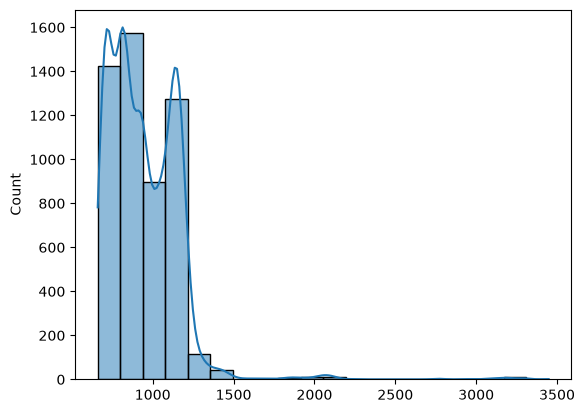

In [33]:
if COMPUTE_LENGTHS:
    MAX_LENGTH = 2048

    tokenizer = AutoTokenizer.from_pretrained(
        "google/gemma-3-4b-it",
        # "google/gemma-3-1b-pt",
    )

    sizes = []
    walk_sizes = []
    system_prompt = model._get_system_prompt_with_neighbours()

    for edge in tqdm(test_edges, desc="Computando tamanhos das vizinhanças serializadas"):
        anchor_node = edge["u"]
        neighborhood_representation = neigh_serializer.get_neighbourhood_representation(anchor_node, return_json_str=False)
        walk_sizes.append(len(neighborhood_representation[0]["walk"]))
        user_prompt = model._get_user_prompt_with_neighbours(
            get_node_info(anchor_node, G),
            get_node_info(edge["v"], G),
            neighborhood_representation[0]["walk"]
        )
        tokenized = tokenizer(system_prompt + user_prompt, truncation=False)
        input_ids = tokenized["input_ids"]
        sizes.append(len(input_ids))
    
    above_max_size = sum(1 for size in sizes if size > MAX_LENGTH)
    print(f"Number of prompts above max length ({MAX_LENGTH}): {above_max_size}. {above_max_size / len(sizes) * 100:.2f}% of total prompts.")
    # max, min, média, mediana e quartis
    print(f"Tamanho máximo: {max(sizes)} tokens")
    print(f"Tamanho mínimo: {min(sizes)} tokens")
    print(f"Tamanho médio: {sum(sizes) / len(sizes):.2f} tokens")
    print(f"Tamanho mediano: {np.median(sizes)} tokens")
    print(f"1º quartil: {np.percentile(sizes, 25)} tokens")
    print(f"3º quartil: {np.percentile(sizes, 75)} tokens") 
    print(f"Percentil 90: {np.percentile(sizes, 90)} tokens")

    sns.histplot(sizes, bins=20, kde=True)

Tamanho máximo da caminhada: 4
Tamanho mínimo da caminhada: 0
Tamanho médio da caminhada: 1.92
Tamanho mediano da caminhada: 2.0
1º quartil da caminhada: 1.0
3º quartil da caminhada: 3.0
Percentil 90 da caminhada: 4.0
Number of walks above max length: 0. 0.00% of total walks.


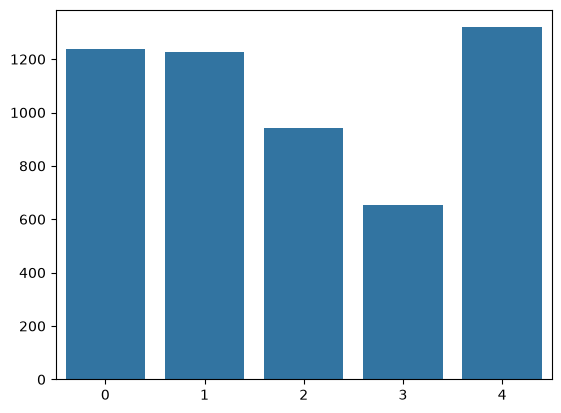

In [ ]:
if COMPUTE_LENGTHS:
    # tamanhos de caminhada
    MAX_LENGTH = 2048
    print(f"Tamanho máximo da caminhada: {max(walk_sizes)}")
    print(f"Tamanho mínimo da caminhada: {min(walk_sizes)}")
    print(f"Tamanho médio da caminhada: {sum(walk_sizes) / len(walk_sizes):.2f}")
    print(f"Tamanho mediano da caminhada: {np.median(walk_sizes)}")
    print(f"1º quartil da caminhada: {np.percentile(walk_sizes, 25)}")
    print(f"3º quartil da caminhada: {np.percentile(walk_sizes, 75)}")
    print(f"Percentil 90 da caminhada: {np.percentile(walk_sizes, 90)}")
    max_size = max(walk_sizes)
    walk_size_counts = {size: walk_sizes.count(size) for size in set(walk_sizes)}
    sns.barplot(x=list(walk_size_counts.keys()), y=list(walk_size_counts.values()))